# 目标建筑数据处理与相似性分析

## 内容：
1. 目标建筑数据预处理
2. VMD-DTW相似性分析
3. 小样本数据集分割

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from vmdpy import VMD
from dtaidistance import dtw

BASE_DIR = Path('data')
SEED = 42
np.random.seed(SEED)

plt.style.use('default')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 目标建筑数据预处理

复用 `data_preprocess.ipynb` 中的预处理逻辑

In [2]:
def build_hr_load_series(
    raw_df: pd.DataFrame,
    ts_col: str,
    cumulative_col: str,
    hr_load_col: str = "hourly_kwh",
):
    df = raw_df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col])
    df = df.sort_values(ts_col).set_index(ts_col)
    df = df.asfreq("1h")
    df[cumulative_col] = pd.to_numeric(df[cumulative_col], errors="coerce").astype(np.float64)
    df[hr_load_col] = df[cumulative_col].diff(1)
    df[hr_load_col] = df[hr_load_col].mask(df[hr_load_col].le(0), np.nan)
    return df


def fill_missing(s: pd.Series):
    s_filled = s.copy()
    for lookback_days in [7, 14]:
        shifted_list = [s_filled.shift(24 * d) for d in range(1, lookback_days + 1)]
        hist_df = pd.concat(shifted_list, axis=1)
        valid_cnt = hist_df.notna().sum(axis=1)
        hist_mean = hist_df.mean(axis=1, skipna=True)
        fill_mask = s_filled.isna() & (valid_cnt >= 2)
        s_filled.loc[fill_mask] = hist_mean.loc[fill_mask]
    s_filled = s_filled.interpolate(method="time", limit_direction="forward").ffill()
    return s_filled


def detect_outliers(s: pd.Series, window: int = 168, threshold: float = 3.0) -> pd.Series:
    s_num = s.copy()
    rolling_median = s_num.rolling(window=window, center=True, min_periods=window).median()
    rolling_mad = s_num.rolling(window=window, center=True, min_periods=window).apply(
        lambda x: np.median(np.abs(x - np.median(x))), raw=True
    )
    abs_dev = (s_num - rolling_median).abs()
    ratio = abs_dev / rolling_mad.replace(0, np.nan)
    outlier_mask = ratio > threshold
    zero_mad_fallback = (rolling_mad == 0) & (abs_dev > 0)
    outlier_mask = outlier_mask | zero_mad_fallback
    return outlier_mask.fillna(False)

In [3]:
# 读取目标负荷数据
target_raw_df = pd.read_csv(BASE_DIR / '目标负荷.CSV', encoding='utf-8')

# 预处理
target_clean_df = build_hr_load_series(
    target_raw_df,
    ts_col="timestamp",
    cumulative_col="load_kwh",
    hr_load_col="hourly_kwh",
)

# 异常值检测
target_clean_df["is_outlier_mad"] = detect_outliers(target_clean_df["hourly_kwh"])
s_no_outlier = target_clean_df["hourly_kwh"].mask(target_clean_df["is_outlier_mad"], np.nan)
target_clean_df["hourly_kwh_clean"] = fill_missing(s_no_outlier).round(2)

# 保存预处理结果
output_path = BASE_DIR / '目标负荷_预处理后.csv'
target_clean_df.reset_index().to_csv(output_path, index=False, encoding='utf-8-sig')

## VMD-DTW相似性分析

1. **VMD分解**：将负荷序列分解为多个IMF（本征模态函数），分别代表不同频率成分
2. **DTW距离**：计算源建筑与目标建筑各IMF的动态时间规整距离
3. **综合相似度**：基于各IMF的DTW距离加权计算整体相似度
4. **可视化**：K值确定、原始负荷对比、各IMF分量对比

In [4]:
# 读取源建筑预处理后的数据
source_clean_df = pd.read_csv(BASE_DIR / '负荷_预处理后.csv', encoding='utf-8-sig')
source_clean_df['timestamp'] = pd.to_datetime(source_clean_df['timestamp'])
source_clean_df = source_clean_df.set_index('timestamp').asfreq('1h')

# 读取目标建筑预处理后的数据
target_clean_df = pd.read_csv(BASE_DIR / '目标负荷_预处理后.csv', encoding='utf-8-sig')
target_clean_df['timestamp'] = pd.to_datetime(target_clean_df['timestamp'])
target_clean_df = target_clean_df.set_index('timestamp').asfreq('1h')

print("源建筑数据:")
print(f"  时间范围: {source_clean_df.index.min()} ~ {source_clean_df.index.max()}")
print(f"  有效样本: {source_clean_df['hourly_kwh_clean'].notna().sum()}")

print("\n目标建筑数据:")
print(f"  时间范围: {target_clean_df.index.min()} ~ {target_clean_df.index.max()}")
print(f"  有效样本: {target_clean_df['hourly_kwh_clean'].notna().sum()}")

# 使用两者共有的时间段且数据完整的部分
source_load = source_clean_df['hourly_kwh_clean'].dropna()
target_load = target_clean_df['hourly_kwh_clean'].dropna()
common_idx = source_load.index.intersection(target_load.index)
print(f"\n共同时间范围: {common_idx.min()} ~ {common_idx.max()}")
print(f"共同样本数: {len(common_idx)}")

源建筑数据:
  时间范围: 2024-01-01 00:00:00 ~ 2024-12-31 23:00:00
  有效样本: 8783

目标建筑数据:
  时间范围: 2024-01-01 00:00:00 ~ 2024-12-31 23:00:00
  有效样本: 8552

共同时间范围: 2024-01-10 16:00:00 ~ 2024-12-31 23:00:00
共同样本数: 8552


In [5]:
# 确定VMD分解层数K（基于中心频率稳定性）
print("="*60)
print("1. 确定VMD最优分解层数K")
print("="*60)

# 数据区间配置
analysis_start = '2024-03-01'
analysis_end = '2024-07-01'

analysis_idx = common_idx[(common_idx >= analysis_start) & (common_idx < analysis_end)]
source_aligned = source_load.loc[analysis_idx].values.astype(np.float64)
target_aligned = target_load.loc[analysis_idx].values.astype(np.float64)

print(f"分析区间: {analysis_idx.min()} ~ {analysis_idx.max()}")
print(f"样本数: {len(analysis_idx)}")

# 测试不同K值下最后一层的中心频率
alpha = 2000
center_freq_results = []
for K_test in range(1, 7):
    _, _, omega_test = VMD(source_aligned, alpha, 0, K_test, 0, 1, 1e-7)
    last_freq = omega_test[-1, -1]
    center_freq_results.append({'K': K_test, 'last_center_freq': last_freq})
    print(f"  K={K_test}: 最后一层中心频率 = {last_freq:.6f}")

# 确定最优K：选择中心频率变化最小的K（趋于稳定）
freq_df = pd.DataFrame(center_freq_results)
freq_df['freq_change'] = freq_df['last_center_freq'].diff().abs()
print(f"\n中心频率变化:")
for _, row in freq_df.iterrows():
    change_str = f"变化: {row['freq_change']:.6f}" if pd.notna(row['freq_change']) else "变化: -"
    print(f"  K={int(row['K'])}: {change_str}")

# 选择变化最小的K值
min_change_idx = freq_df['freq_change'].idxmin()
optimal_K = int(freq_df.loc[min_change_idx, 'K'])
print(f"\n最小变化: {freq_df.loc[min_change_idx, 'freq_change']:.6f}，选择最优 K = {optimal_K}")

# VMD分解
print("\n" + "="*60)
print(f"2. VMD分解 (K={optimal_K})")
print("="*60)

K = optimal_K
u_source, _, omega_source = VMD(source_aligned, alpha, 0, K, 0, 1, 1e-7)
u_target, _, omega_target = VMD(target_aligned, alpha, 0, K, 0, 1, 1e-7)

print(f"\n源建筑各IMF中心频率:")
for i in range(K):
    print(f"  IMF{i+1}: {omega_source[-1, i]:.6f}")

# 计算各层DTW距离
print("\n" + "="*60)
print("3. 计算各层DTW距离")
print("="*60)

dtw_distances = []
for i in range(K):
    s1 = u_source[i, :].astype(np.float64)
    s2 = u_target[i, :].astype(np.float64)
    dtw_dist = dtw.distance(s1, s2, use_pruning=True)
    dtw_distances.append(dtw_dist)
    print(f"  IMF{i+1}: DTW距离 = {dtw_dist:.2f}")

# 原始序列DTW距离
dtw_original = dtw.distance(source_aligned, target_aligned, use_pruning=True)
print(f"\n原始序列DTW距离: {dtw_original:.2f}")

# 加权DTW计算（低层权重大，高层权重小）
print("\n" + "="*60)
print("4. 加权DTW距离计算")
print("="*60)

if K == 3:
    weights = np.array([6, 3, 1])
elif K == 4:
    weights = np.array([6, 3, 2, 1])
elif K == 5:
    weights = np.array([8, 4, 2, 1, 1])
else:
    weights = np.array([8] + [4] * (K-2) + [1])

weights_norm = weights / weights.sum()
print(f"权重比: {':'.join(map(str, weights))}")
print(f"归一化权重: {':'.join(map(str, weights_norm.round(4)))}")

weighted_dtw = np.sum(np.array(dtw_distances) * weights_norm)
print(f"加权DTW距离: {weighted_dtw:.2f}")

# 相似度评估
print("\n" + "="*60)
print("5. VMD-DTW相似性分析结果")
print("="*60)

max_dtw = max(dtw_original, weighted_dtw)
similarity = 1 - (weighted_dtw / max_dtw) if max_dtw > 0 else 0

print(f"加权DTW距离: {weighted_dtw:.2f}")
print(f"原始序列DTW距离: {dtw_original:.2f}")
print(f"综合相似度: {similarity:.4f} ({similarity*100:.2f}%)")

# 保存结果
result_df = pd.DataFrame({
    'IMF': [f'IMF{i+1}' for i in range(K)],
    'DTW距离': dtw_distances,
    '中心频率': omega_source[-1, :],
    '权重': weights_norm
})
result_df.to_csv(BASE_DIR / 'VMD_DTW分析结果.csv', index=False, encoding='utf-8-sig')
print(f"\n分析结果已保存至: {BASE_DIR / 'VMD_DTW分析结果.csv'}")

# 保存结果字典供后续使用
result = {
    'common_index': analysis_idx,
    'u_source': u_source,
    'u_target': u_target,
    'omega_source': omega_source,
    'omega_target': omega_target,
    'dtw_distances': dtw_distances,
    'dtw_original': dtw_original,
    'weighted_dtw': weighted_dtw,
    'weights': weights_norm,
    'similarity': similarity,
    'optimal_K': K,
    'center_freq_results': center_freq_results,
}

1. 确定VMD最优分解层数K
分析区间: 2024-03-01 00:00:00 ~ 2024-06-30 23:00:00
样本数: 2928
  K=1: 最后一层中心频率 = 0.000619
  K=2: 最后一层中心频率 = 0.123695
  K=3: 最后一层中心频率 = 0.289712
  K=4: 最后一层中心频率 = 0.329945
  K=5: 最后一层中心频率 = 0.336588
  K=6: 最后一层中心频率 = 0.415292

中心频率变化:
  K=1: 变化: -
  K=2: 变化: 0.123076
  K=3: 变化: 0.166017
  K=4: 变化: 0.040233
  K=5: 变化: 0.006643
  K=6: 变化: 0.078704

最小变化: 0.006643，选择最优 K = 5

2. VMD分解 (K=5)

源建筑各IMF中心频率:
  IMF1: 0.000206
  IMF2: 0.041346
  IMF3: 0.161399
  IMF4: 0.288171
  IMF5: 0.336588

3. 计算各层DTW距离
  IMF1: DTW距离 = 209.57
  IMF2: DTW距离 = 170.70
  IMF3: DTW距离 = 91.35
  IMF4: DTW距离 = 36.14
  IMF5: DTW距离 = 37.93

原始序列DTW距离: 385.06

4. 加权DTW距离计算
权重比: 8:4:2:1:1
归一化权重: 0.5:0.25:0.125:0.0625:0.0625
加权DTW距离: 163.51

5. VMD-DTW相似性分析结果
加权DTW距离: 163.51
原始序列DTW距离: 385.06
综合相似度: 0.5754 (57.54%)

分析结果已保存至: data\VMD_DTW分析结果.csv


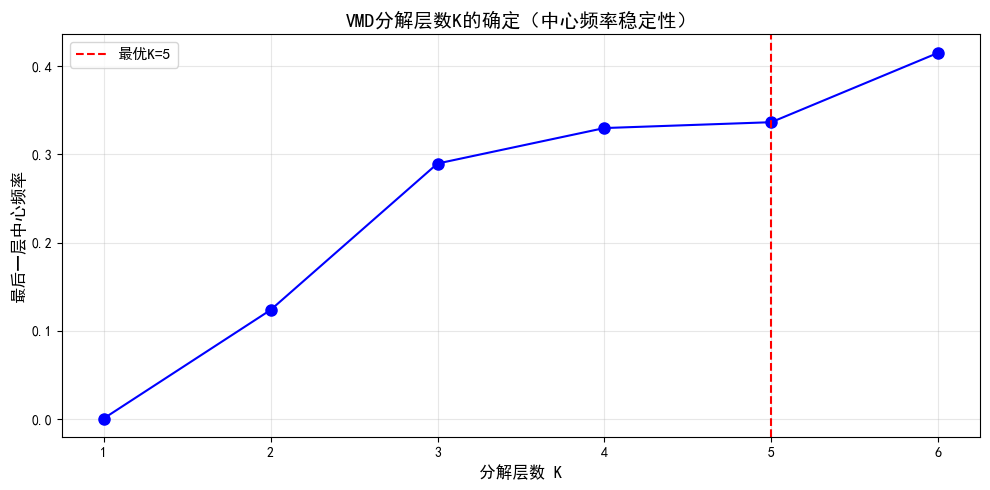

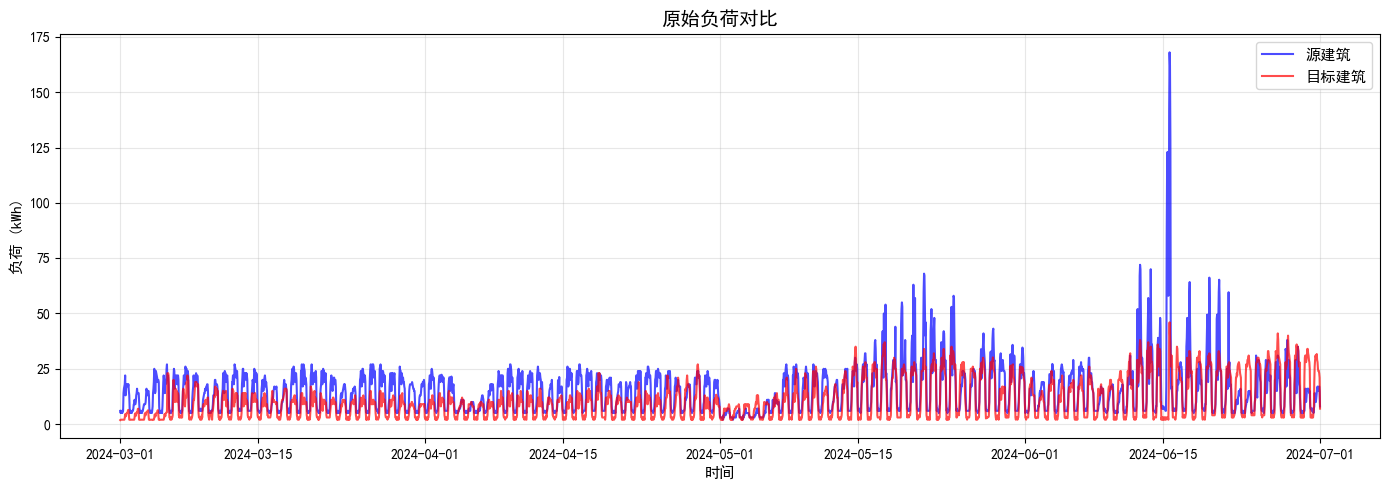

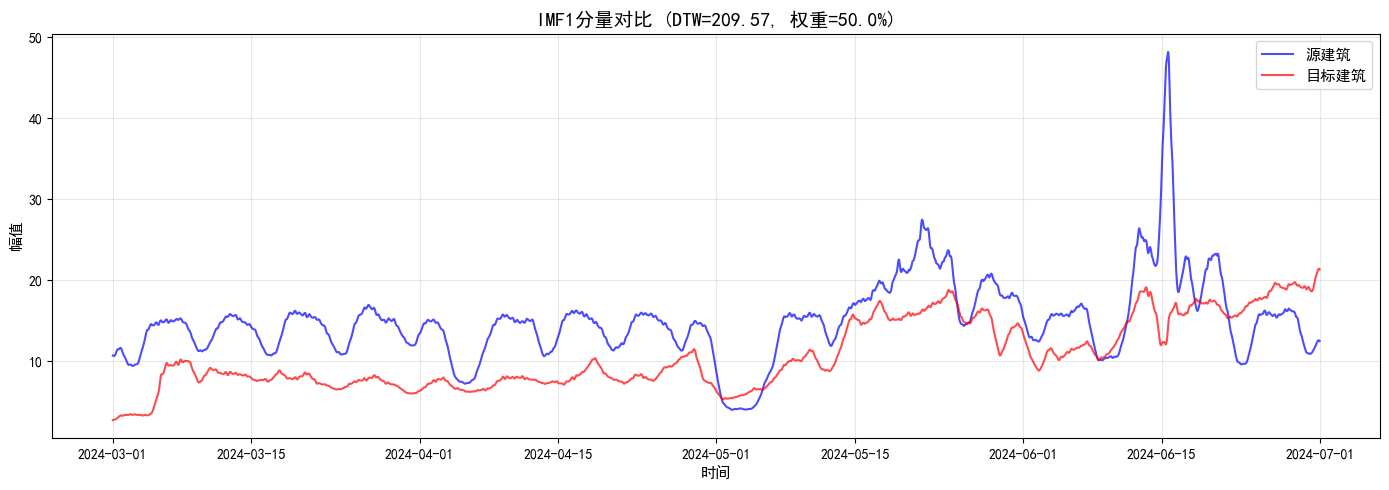

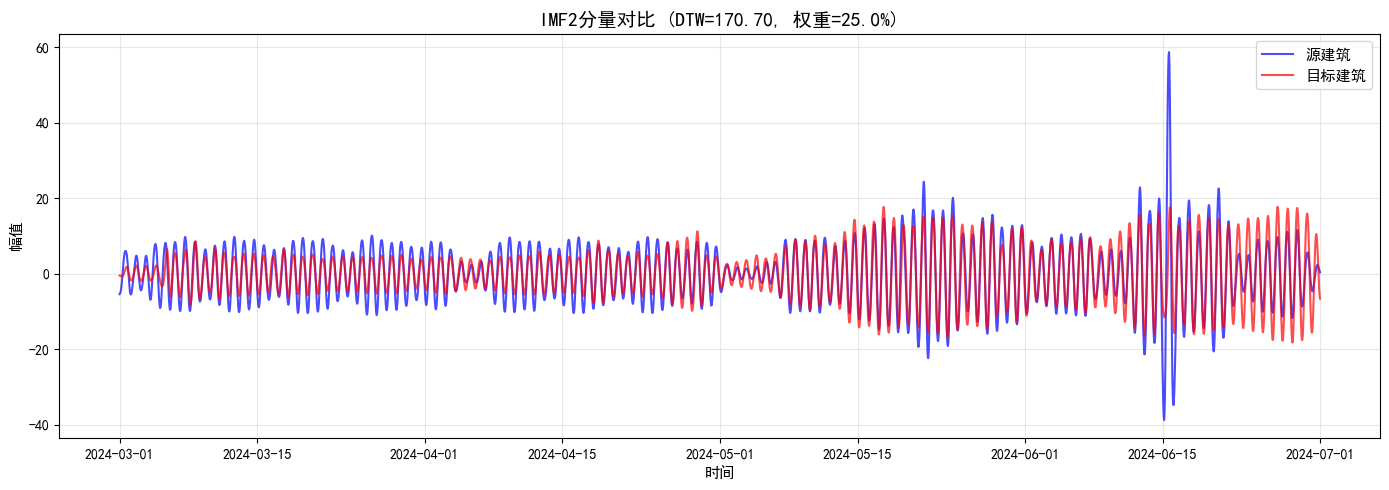

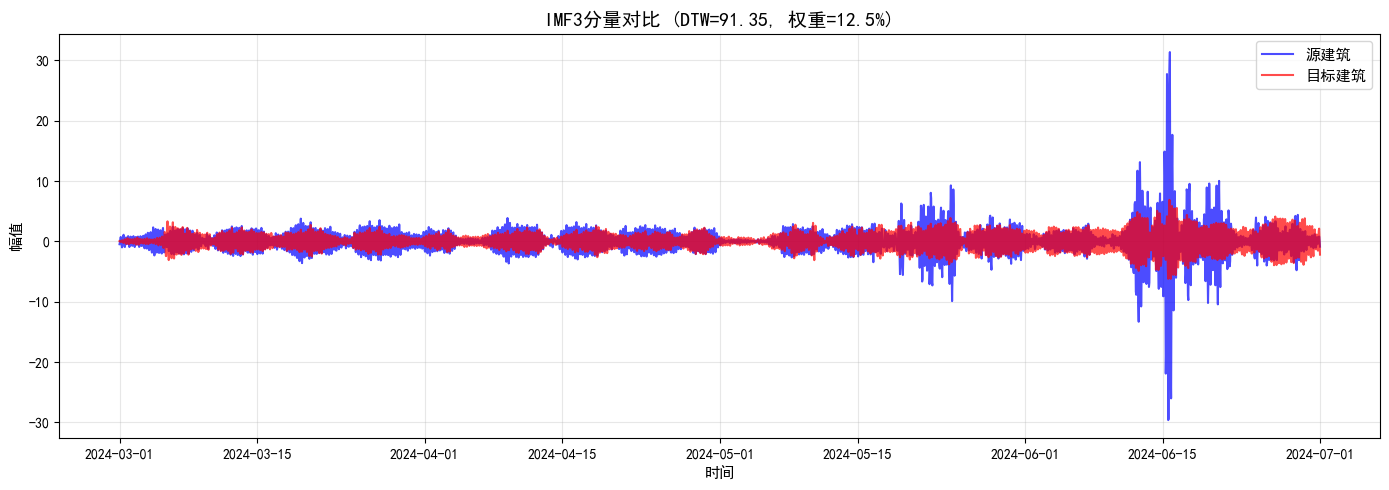

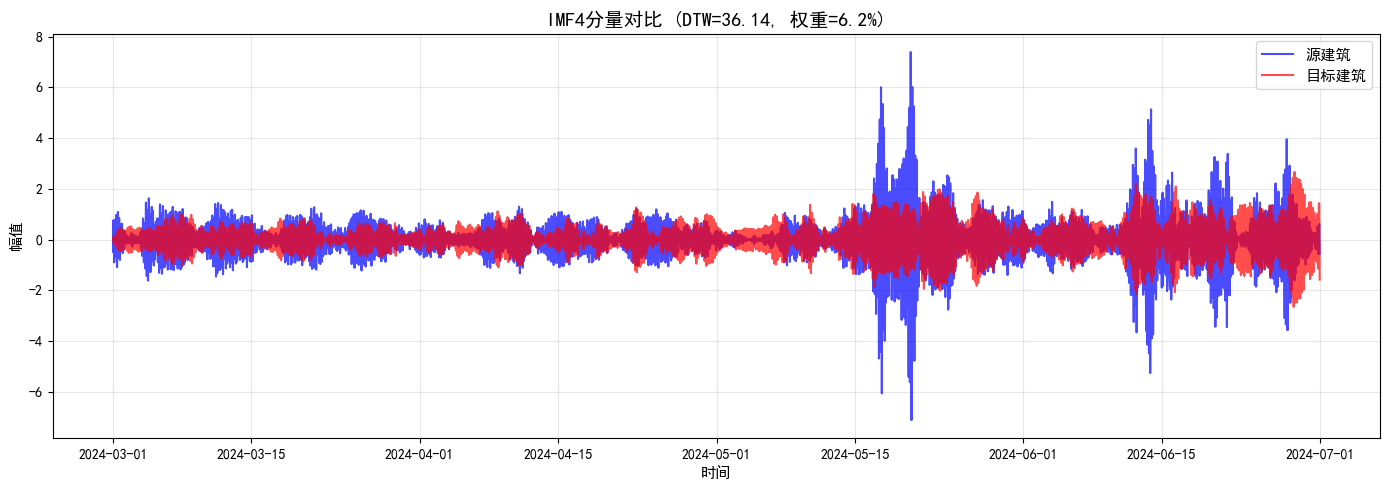

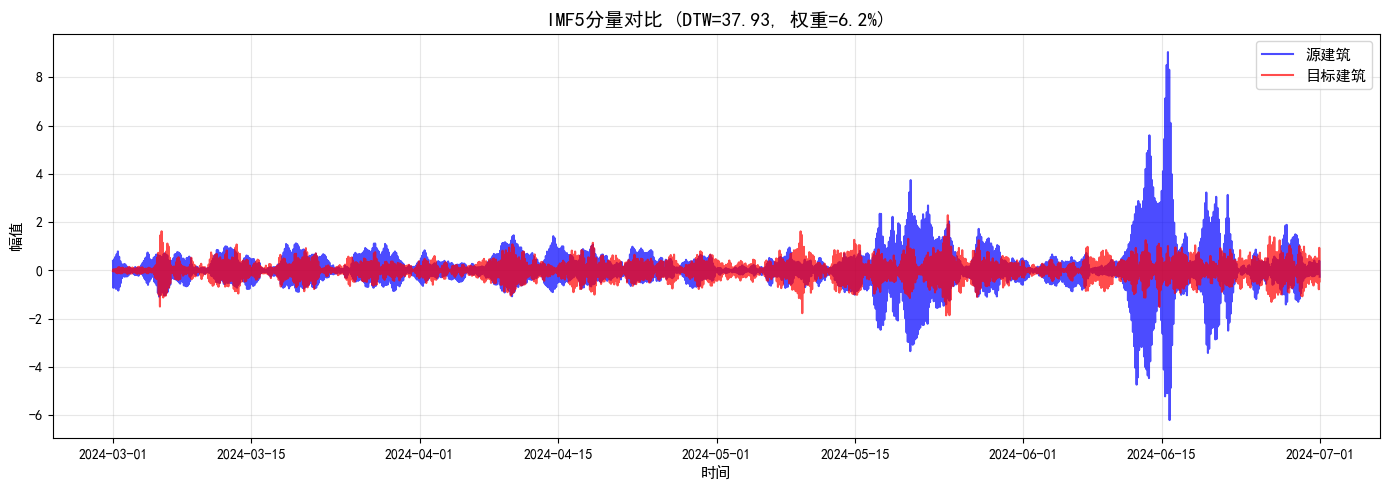

In [11]:
# K值确定
fig1, ax1 = plt.subplots(figsize=(10, 5))
freq_df = pd.DataFrame(result['center_freq_results'])
ax1.plot(freq_df['K'], freq_df['last_center_freq'], 'bo-', markersize=8)
ax1.axvline(x=result['optimal_K'], color='r', linestyle='--', label=f'最优K={result["optimal_K"]}')
ax1.set_xlabel('分解层数 K', fontsize=12)
ax1.set_ylabel('最后一层中心频率', fontsize=12)
ax1.set_title('VMD分解层数K的确定（中心频率稳定性）', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 原始负荷对比（单图叠加显示）
common_idx = result['common_index']
source_plot = source_load.loc[common_idx].values
target_plot = target_load.loc[common_idx].values

fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(common_idx, source_plot, 'b-', alpha=0.7, label='源建筑')
ax2.plot(common_idx, target_plot, 'r-', alpha=0.7, label='目标建筑')
ax2.set_title('原始负荷对比', fontsize=14)
ax2.set_xlabel('时间', fontsize=11)
ax2.set_ylabel('负荷 (kWh)', fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / '原始负荷对比.png', dpi=150, bbox_inches='tight')
plt.show()

# 各IMF分量对比（单图叠加显示）
for i in range(K):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(common_idx, result['u_source'][i, :], 'b-', alpha=0.7, label='源建筑')
    ax.plot(common_idx, result['u_target'][i, :], 'r-', alpha=0.7, label='目标建筑')
    ax.set_title(f'IMF{i+1}分量对比 (DTW={result["dtw_distances"][i]:.2f}, 权重={result["weights"][i]*100:.1f}%)', fontsize=14)
    ax.set_xlabel('时间', fontsize=11)
    ax.set_ylabel('幅值', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(BASE_DIR / f'IMF{i+1}对比.png', dpi=150, bbox_inches='tight')
    plt.show()

## 典型周可视化

选择周均负荷最接近整体均值的周，最能代表该时段的负荷特征作为典型周

1. 典型周负荷曲线对比
2. 日均负荷模式对比

分析时段内共有 18 周
整体平均负荷 - 源建筑: 14.95 kWh, 目标建筑: 10.67 kWh
选择第 23 周作为典型周


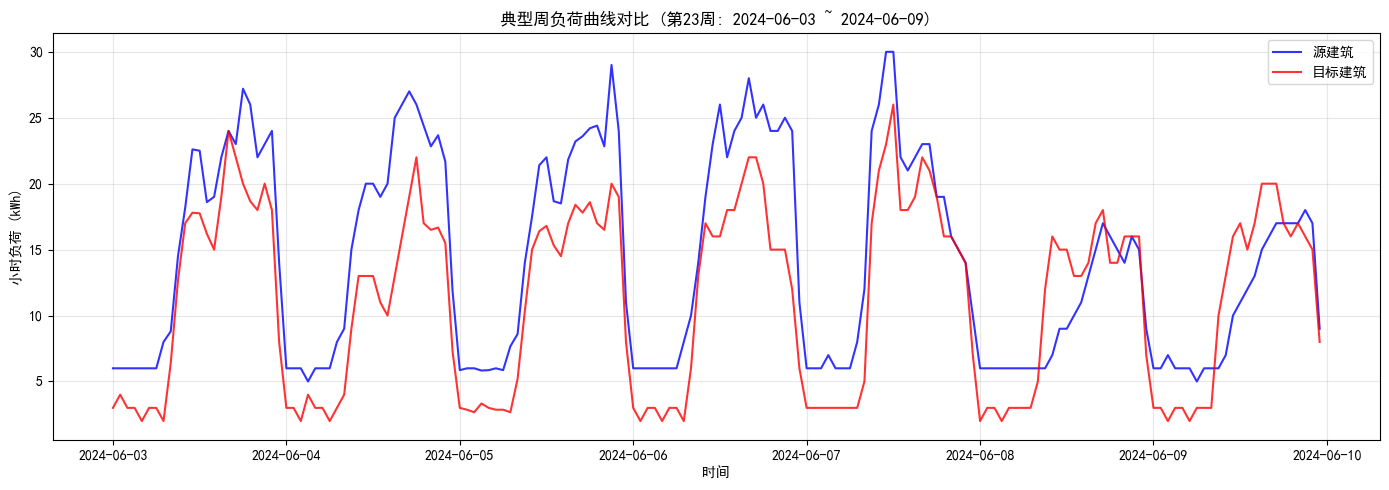

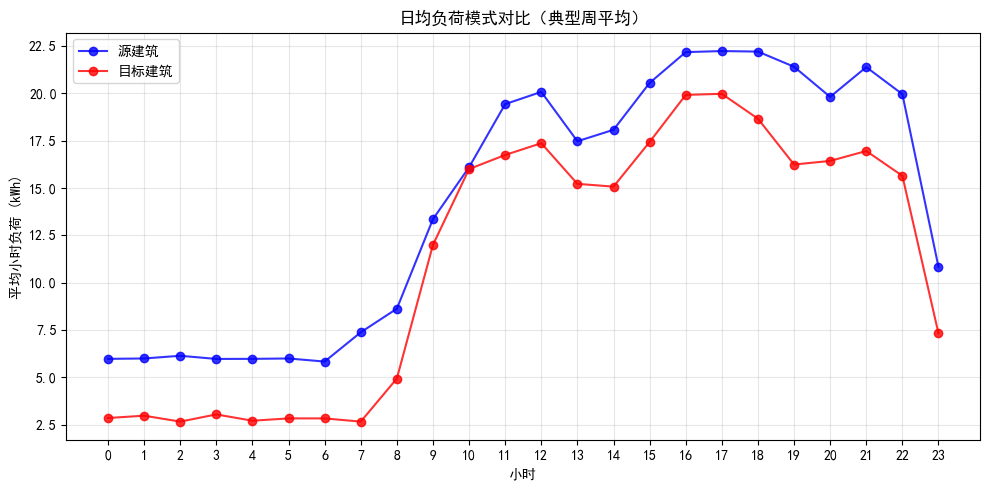

In [7]:
common_idx = result['common_index']

# 按周划分数据
df_weekly = pd.DataFrame({'source': source_load.loc[common_idx].values,
                          'target': target_load.loc[common_idx].values},
                         index=common_idx)
df_weekly['week'] = df_weekly.index.isocalendar().week

# 计算每周的平均负荷
weekly_stats = df_weekly.groupby('week').agg({
    'source': 'mean',
    'target': 'mean'
}).reset_index()

# 计算整体平均负荷
overall_mean_source = df_weekly['source'].mean()
overall_mean_target = df_weekly['target'].mean()

# 选择最接近整体均值的周（综合源建筑和目标建筑）
weekly_stats['source_diff'] = abs(weekly_stats['source'] - overall_mean_source)
weekly_stats['target_diff'] = abs(weekly_stats['target'] - overall_mean_target)
weekly_stats['total_diff'] = weekly_stats['source_diff'] + weekly_stats['target_diff']

typical_week = weekly_stats.loc[weekly_stats['total_diff'].idxmin(), 'week']
print(f"分析时段内共有 {len(weekly_stats)} 周")
print(f"整体平均负荷 - 源建筑: {overall_mean_source:.2f} kWh, 目标建筑: {overall_mean_target:.2f} kWh")
print(f"选择第 {int(typical_week)} 周作为典型周")

# 提取典型周数据
typical_week_idx = common_idx[common_idx.isocalendar().week == typical_week]

if len(typical_week_idx) >= 24:  # 至少有一天数据
    source_typical = source_load.loc[typical_week_idx]
    target_typical = target_load.loc[typical_week_idx]
    
    # 图1：典型周负荷曲线对比
    fig1, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(typical_week_idx, source_typical.values, 'b-', label='源建筑', alpha=0.8)
    ax1.plot(typical_week_idx, target_typical.values, 'r-', label='目标建筑', alpha=0.8)
    ax1.set_xlabel('时间')
    ax1.set_ylabel('小时负荷 (kWh)')
    week_start_date = typical_week_idx.min().strftime('%Y-%m-%d')
    week_end_date = typical_week_idx.max().strftime('%Y-%m-%d')
    ax1.set_title(f'典型周负荷曲线对比 (第{int(typical_week)}周: {week_start_date} ~ {week_end_date})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(BASE_DIR / '典型周负荷曲线对比.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 图2：日均负荷模式对比
    source_daily_pattern = source_typical.groupby(source_typical.index.hour).mean()
    target_daily_pattern = target_typical.groupby(target_typical.index.hour).mean()
    
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(range(24), source_daily_pattern.values, 'b-o', label='源建筑', alpha=0.8)
    ax2.plot(range(24), target_daily_pattern.values, 'r-o', label='目标建筑', alpha=0.8)
    ax2.set_xlabel('小时')
    ax2.set_ylabel('平均小时负荷 (kWh)')
    ax2.set_title(f'日均负荷模式对比（典型周平均）')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(24))
    plt.tight_layout()
    plt.savefig(BASE_DIR / '日均负荷模式对比.png', dpi=150, bbox_inches='tight')
    plt.show()

## 小样本数据集分割

**分割策略**：训练集 70% : 验证集 15% : 测试集 15%

In [8]:
def split_target_dataset(
    df: pd.DataFrame,
    start_date: str,
    end_date: str,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
    output_dir: Path = BASE_DIR,
):
    # 筛选时间范围
    mask = (df.index >= start_date) & (df.index < end_date)
    df_selected = df.loc[mask].copy()
    
    # 确保数据完整
    df_selected = df_selected[df_selected['hourly_kwh_clean'].notna()]
    n_samples = len(df_selected)
    
    # 计算分割点
    n_train = int(n_samples * train_ratio)
    n_val = int(n_samples * val_ratio)
    n_test = n_samples - n_train - n_val

    train_df = df_selected.iloc[:n_train]
    val_df = df_selected.iloc[n_train:n_train + n_val]
    test_df = df_selected.iloc[n_train + n_val:]
    
    print(f"数据分割结果 (训练:{train_ratio*100:.0f}% / 验证:{val_ratio*100:.0f}% / 测试:{test_ratio*100:.0f}%):")
    print(f"  训练集: {train_df.index.min()} ~ {train_df.index.max()} ({len(train_df)} 样本)")
    print(f"  验证集: {val_df.index.min()} ~ {val_df.index.max()} ({len(val_df)} 样本)")
    print(f"  测试集: {test_df.index.min()} ~ {test_df.index.max()} ({len(test_df)} 样本)")

    train_df.reset_index().to_csv(output_dir / 'target_train.csv', index=False, encoding='utf-8-sig')
    val_df.reset_index().to_csv(output_dir / 'target_val.csv', index=False, encoding='utf-8-sig')
    test_df.reset_index().to_csv(output_dir / 'target_test.csv', index=False, encoding='utf-8-sig')
    
    return train_df, val_df, test_df

In [9]:
# 重新加载预处理后的数据
target_df = pd.read_csv(BASE_DIR / '目标负荷_预处理后.csv', encoding='utf-8-sig')
target_df['timestamp'] = pd.to_datetime(target_df['timestamp'])
target_df = target_df.set_index('timestamp').asfreq('1h')

train_df, val_df, test_df = split_target_dataset(
    df=target_df,
    start_date=analysis_start,
    end_date=analysis_end,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    output_dir=BASE_DIR,
)

数据分割结果 (训练:70% / 验证:15% / 测试:15%):
  训练集: 2024-03-01 00:00:00 ~ 2024-05-25 08:00:00 (2049 样本)
  验证集: 2024-05-25 09:00:00 ~ 2024-06-12 15:00:00 (439 样本)
  测试集: 2024-06-12 16:00:00 ~ 2024-06-30 23:00:00 (440 样本)
